Configuring GPU settings...
✓ GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

                          MOBILENET-UNET WITH GLAUCOMA PROGRESSION SCORING                          

Glaucoma Severity Classification:
  Normal:   CDR < 0.3
  Suspect:  0.3 ≤ CDR < 0.6
  Moderate: 0.6 ≤ CDR < 0.8
  Advanced: CDR ≥ 0.8
Loading train data...
  train: 400 samples
Loading val data...
  val: 400 samples
Loading test data...
  test: 400 samples
Split - Train: 600, Val: 200, Test: 400

TRAINING: Deeper_Focal_MC_GlaucomaScoring
  Architecture: Deeper Decoder + Focal-EIoU + MC Dropout
  Loss: Focal + Enhanced IoU (Combined)

Model Configuration:
  Total Parameters: 37,129,475
  Dropout Layers: 5
  Architecture: Deeper Decoder + Focal-EIoU + MC Dropout
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8009 - dice_class_0: 0.8700 - dice_class_1: 0.3183 - dice_class_2: 0.1460 - dice_coef_multiclass: 0.5368 - iou_class_0: 0.8016 - iou_class_1: 0.2074 - iou

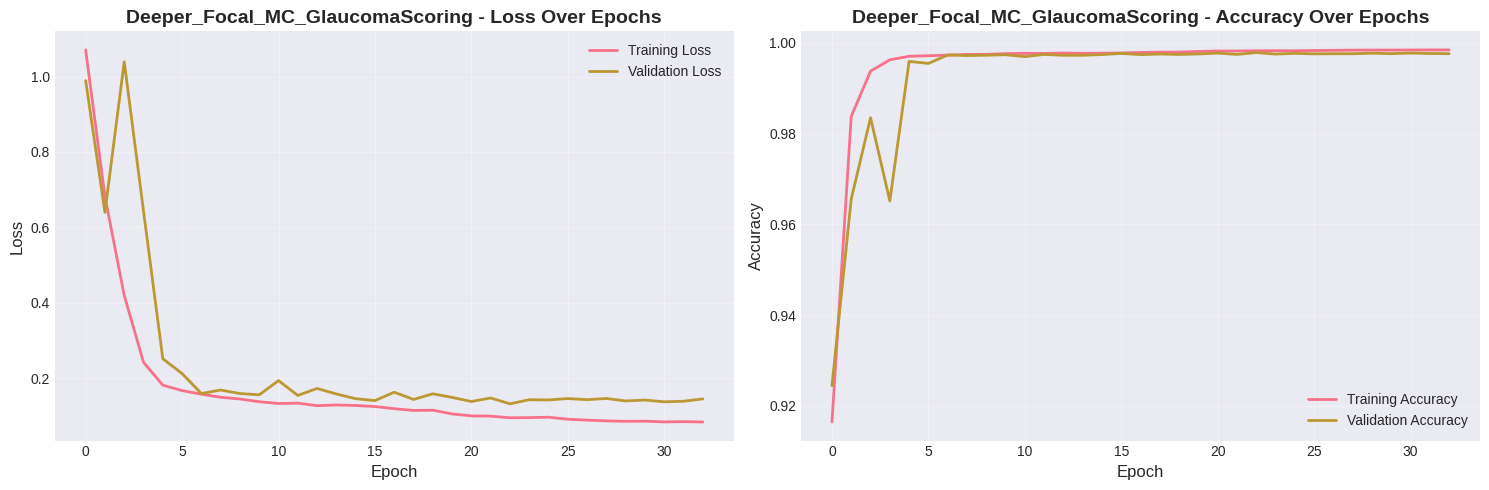

  ✓ Saved: results/Deeper_Focal_MC_GlaucomaScoring_predictions_cdr.png


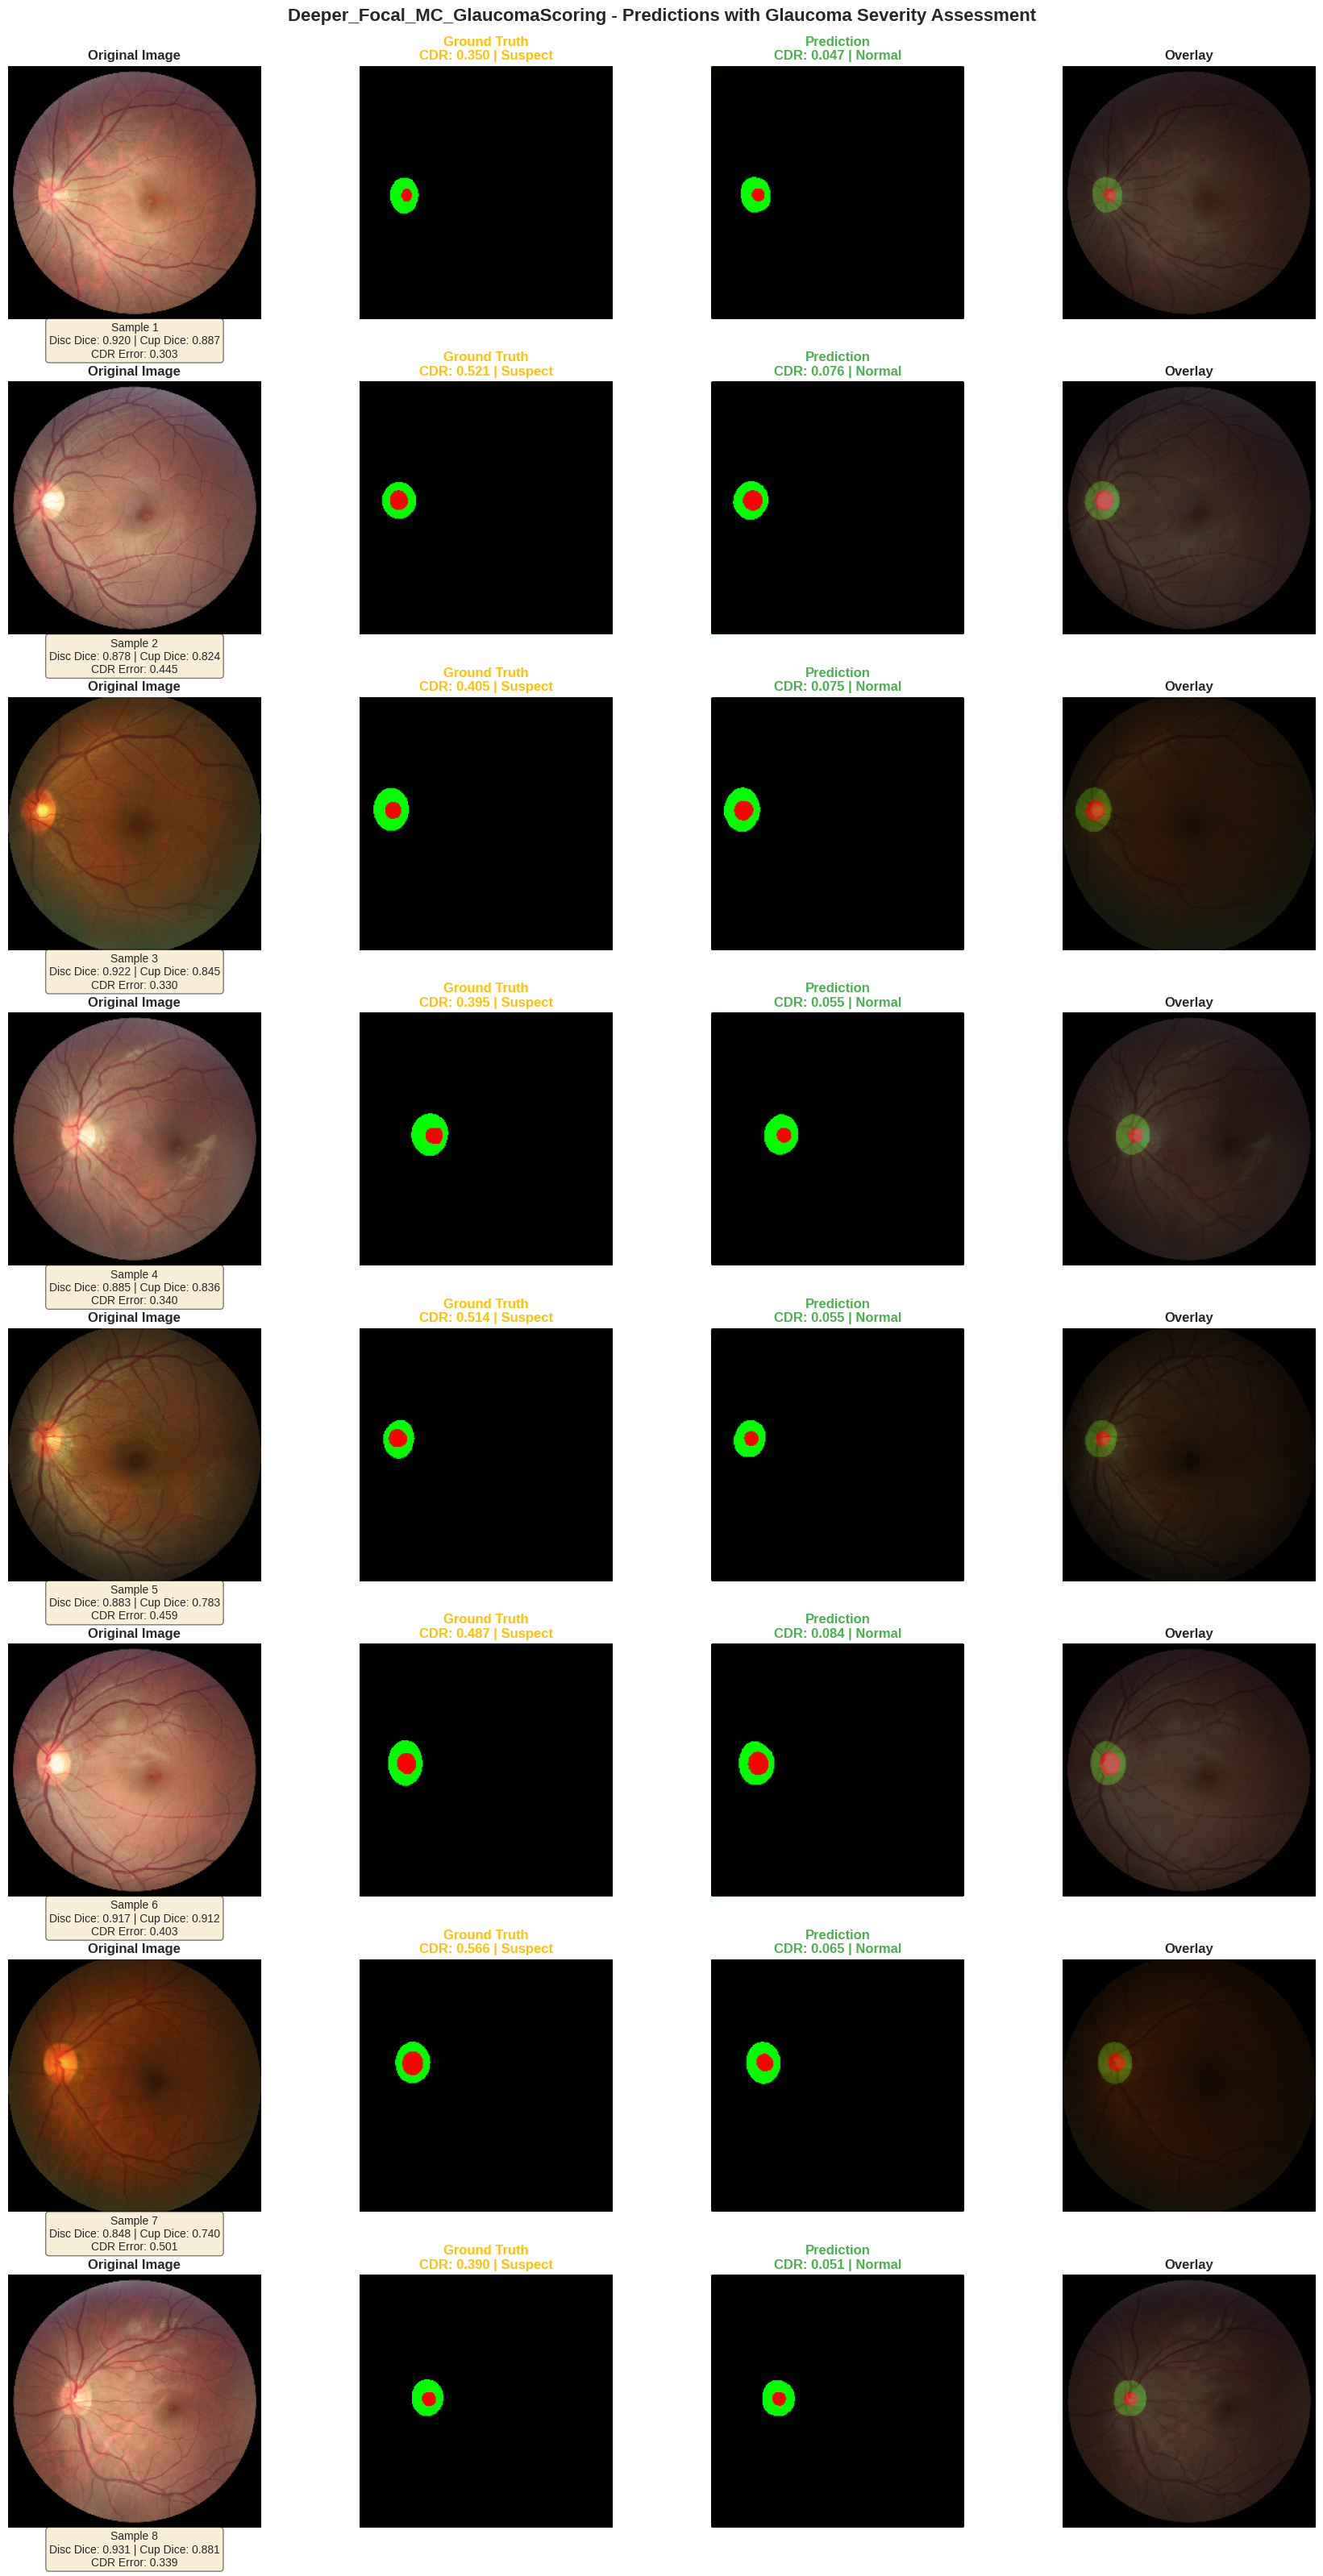


EVALUATION: Deeper+Focal+MC+GlaucomaScoring
  ✓ Saved: results/Deeper+Focal+MC+GlaucomaScoring_confusion_matrices.png


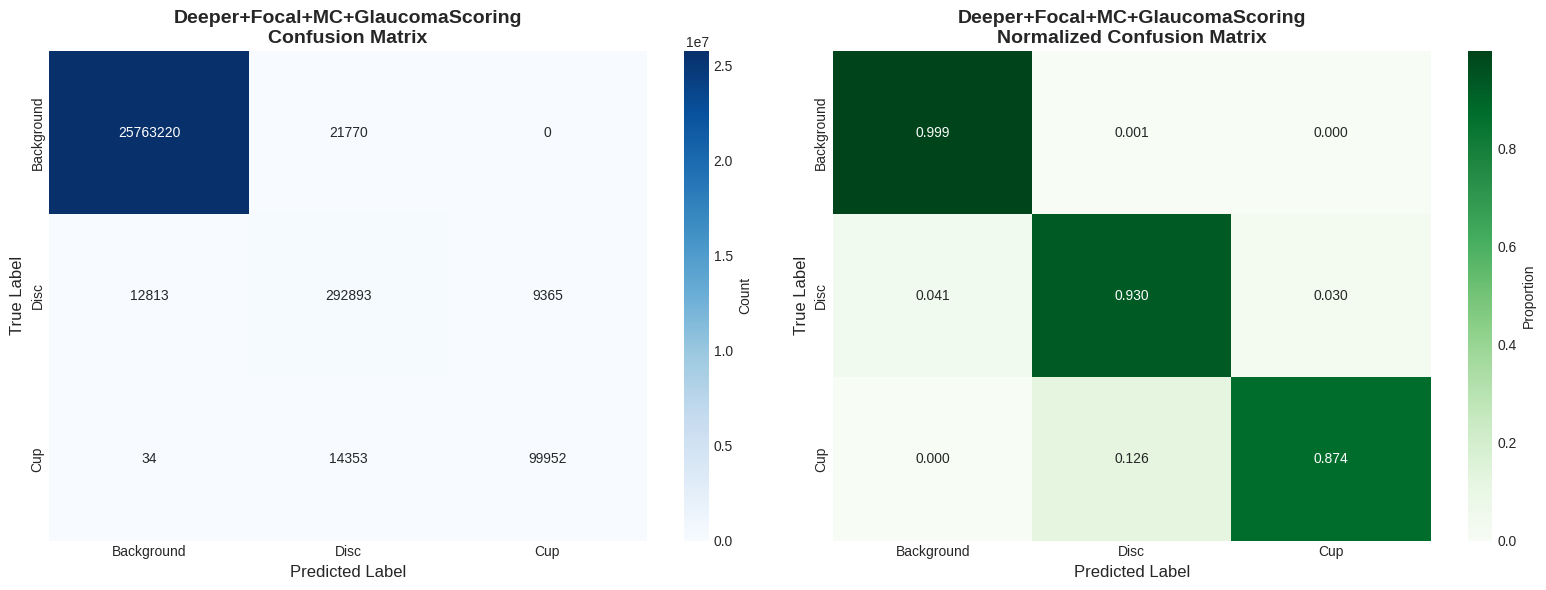


Confusion Matrix:
[[25763220    21770        0]
 [   12813   292893     9365]
 [      34    14353    99952]]

Normalized Confusion Matrix:
[[0.999 0.001 0.   ]
 [0.041 0.93  0.03 ]
 [0.    0.126 0.874]]

Precision, Recall, F1 Score per class:
  Background: Precision=0.9995, Recall=0.9992, F1=0.9993
  Disc: Precision=0.8902, Recall=0.9296, F1=0.9095
  Cup: Precision=0.9143, Recall=0.8742, F1=0.8938

Macro-averaged metrics:
  Precision: 0.9347
  Recall: 0.9343
  F1 Score: 0.9342
  Background: Dice=0.9993, IoU=0.9987
  Disc: Dice=0.9095, IoU=0.8340
  Cup: Dice=0.8938, IoU=0.8080

GLAUCOMA PROGRESSION ANALYSIS

CDR Statistics:
  Mean GT CDR: 0.4894 ± 0.0958
  Mean Pred CDR: 0.0678 ± 0.0164
  Mean CDR Error: 0.4216 ± 0.0837
  Median CDR Error: 0.4069

Severity Classification Accuracy: 0.00%

Ground Truth Severity Distribution:
GT_Severity
Advanced      5
Moderate     43
Suspect     352
Name: count, dtype: int64

Predicted Severity Distribution:
Pred_Severity
Normal    400
Name: count, dtyp

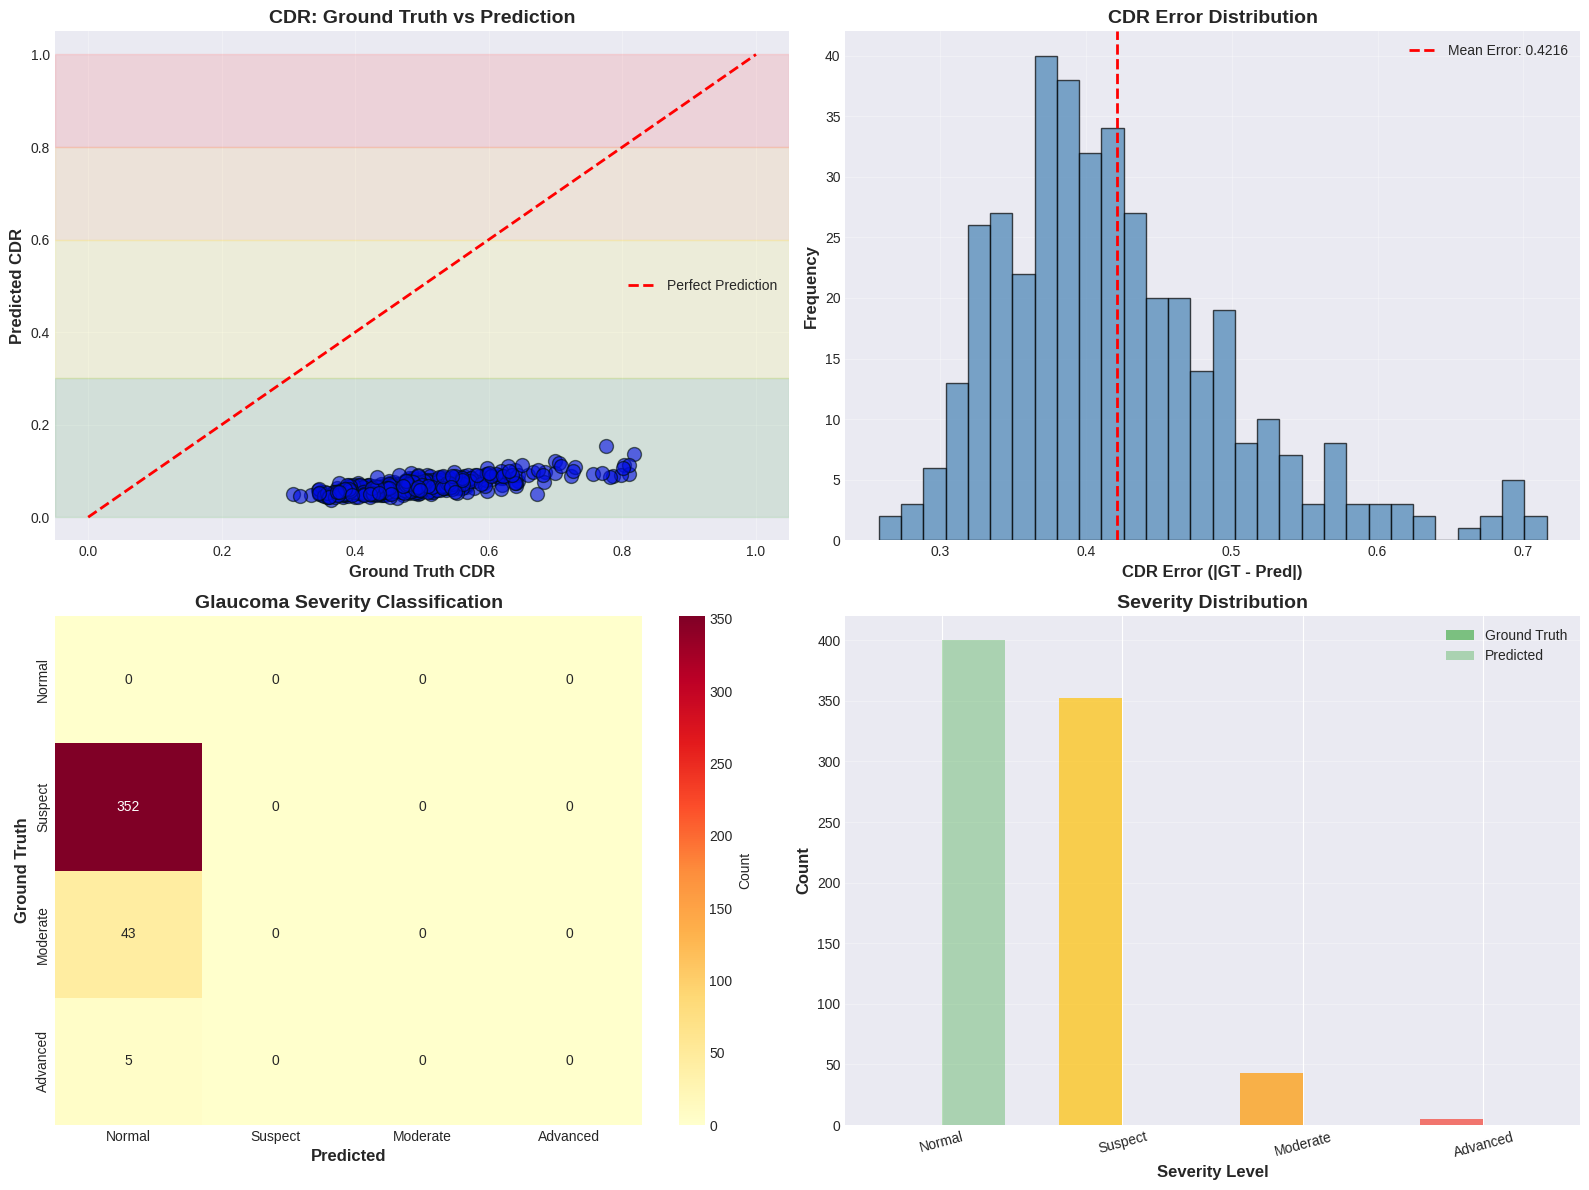


MC DROPOUT UNCERTAINTY ESTIMATION

Running MC Dropout with 15 stochastic forward passes...
  Completed: 5/15 forward passes
  Completed: 10/15 forward passes
  Completed: 15/15 forward passes
✓ MC Dropout completed
  Background uncertainty: 0.0002
  Disc uncertainty: 0.0004
  Cup uncertainty: 0.0002

                                ✓ TRAINING AND EVALUATION COMPLETED!                                

Model: Deeper + Focal + EIoU + MC Dropout + Glaucoma Scoring
Parameters: 37,129,475
Results saved in: results/

Generated Files:
  - Training history: results/Deeper_Focal_MC_GlaucomaScoring_history.png
  - Predictions with CDR: results/Deeper_Focal_MC_GlaucomaScoring_predictions_cdr.png
  - CDR Analysis: results/cdr_analysis.png
  - Progression CSV: results/glaucoma_progression_analysis.csv
  - Confusion Matrices: results/Deeper+Focal+MC+GlaucomaScoring_confusion_matrices.png




In [7]:
"""
MOBILENET-UNET WITH GLAUCOMA PROGRESSION SCORING
=================================================
Enhanced with:
1. Deeper Decoder Architecture
2. Focal-EIoU Combined Loss
3. MC Dropout for Uncertainty Estimation
4. Glaucoma Progression Scoring based on Cup-to-Disc Ratio (CDR)

Glaucoma Scoring System:
- Normal: CDR < 0.3
- Suspect: 0.3 ≤ CDR < 0.6
- Moderate: 0.6 ≤ CDR < 0.8
- Advanced: CDR ≥ 0.8

Additional Features:
- Vertical CDR calculation (vCDR)
- Horizontal CDR calculation (hCDR)
- Average CDR for overall assessment
- Risk classification per sample
- Progression tracking visualization
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import albumentations as A
import warnings
import gc
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# GPU CONFIGURATION
# ============================================================================

def configure_gpu():
    """Configure GPU settings for optimal performance"""
    print("Configuring GPU settings...")
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for gpu in physical_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.config.set_visible_devices(physical_devices[0], 'GPU')
            print(f"✓ GPU found: {physical_devices}")
            return True
        except RuntimeError as e:
            print(f"✗ GPU configuration error: {e}")
            return False
    else:
        print("✗ No GPU found, using CPU")
        return False

# ============================================================================
# DATA LOADING
# ============================================================================

def load_images_masks(images_folder, masks_folder, img_size=(256,256)):
    """Load images and masks from folders"""
    images, masks = [], []
    image_files = sorted(os.listdir(images_folder))
    mask_files = sorted(os.listdir(masks_folder))
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_file in image_files:
        base = os.path.splitext(img_file)[0]
        if base in mask_dict:
            img = cv2.imread(os.path.join(images_folder, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size) / 255.0
            
            mask = cv2.imread(os.path.join(masks_folder, mask_dict[base]), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, img_size)
            unique_vals = np.unique(mask)
            if len(unique_vals) > 3 or np.max(unique_vals) > 2:
                mask = np.clip(mask // 85, 0, 2).astype(np.uint8)
            
            images.append(img)
            masks.append(mask)
    
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.uint8)

def load_all_data(root_dir):
    """Load all data from existing splits and merge"""
    all_images, all_masks = [], []
    for split in ["train", "val", "test"]:
        print(f"Loading {split} data...")
        imgs, msks = load_images_masks(
            os.path.join(root_dir, split, "Images"),
            os.path.join(root_dir, split, "Masks")
        )
        all_images.append(imgs)
        all_masks.append(msks)
        print(f"  {split}: {imgs.shape[0]} samples")
    
    all_images = np.concatenate(all_images, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    return all_images, all_masks

def create_new_split(all_images, all_masks):
    """Create new split: 600 train, 200 val, 400 test"""
    X_temp, X_test, y_temp, y_test = train_test_split(
        all_images, all_masks, test_size=400, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=200, random_state=42
    )
    print(f"Split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ============================================================================
# DATA AUGMENTATION
# ============================================================================

def setup_augmentations():
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    ])

def data_generator(images, masks, batch_size, augment=None):
    idxs = np.arange(len(images))
    while True:
        np.random.shuffle(idxs)
        for i in range(0, len(images), batch_size):
            batch_idxs = idxs[i:i+batch_size]
            batch_x, batch_y = [], []
            
            for idx in batch_idxs:
                img, mask = images[idx], masks[idx]
                
                if augment:
                    aug = augment(image=img, mask=mask)
                    img_aug, mask_aug = aug['image'], aug['mask']
                else:
                    img_aug, mask_aug = img, mask
                
                mask_cat = to_categorical(mask_aug, num_classes=3)
                batch_x.append(img_aug)
                batch_y.append(mask_cat)
            
            yield np.stack(batch_x).astype(np.float32), np.stack(batch_y).astype(np.float32)

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=None, epsilon=1e-7):
    if alpha is None:
        alpha = [0.25, 1.0, 1.0]
    
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    focal_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        pt = y_pred_c
        focal_weight = K.pow(1.0 - pt, gamma)
        cross_entropy = -K.log(pt)
        focal_loss_c = alpha[c] * focal_weight * cross_entropy * y_true_c
        focal_loss_value += K.mean(focal_loss_c)
    
    return focal_loss_value

def enhanced_iou_loss(y_true, y_pred, smooth=1e-7):
    eiou_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        
        height = K.cast(K.shape(y_true_c)[1], 'float32')
        width = K.cast(K.shape(y_true_c)[2], 'float32')
        
        y_coords = K.arange(0, height)
        x_coords = K.arange(0, width)
        y_grid = K.tile(K.reshape(y_coords, (-1, 1)), (1, K.cast(width, 'int32')))
        x_grid = K.tile(K.reshape(x_coords, (1, -1)), (K.cast(height, 'int32'), 1))
        y_grid = K.cast(y_grid, 'float32')
        x_grid = K.cast(x_grid, 'float32')
        
        true_mass = K.sum(y_true_c, axis=[1, 2]) + smooth
        true_center_y = K.sum(y_true_c * y_grid, axis=[1, 2]) / true_mass
        true_center_x = K.sum(y_true_c * x_grid, axis=[1, 2]) / true_mass
        
        pred_mass = K.sum(y_pred_c, axis=[1, 2]) + smooth
        pred_center_y = K.sum(y_pred_c * y_grid, axis=[1, 2]) / pred_mass
        pred_center_x = K.sum(y_pred_c * x_grid, axis=[1, 2]) / pred_mass
        
        center_distance = K.square(true_center_y - pred_center_y) + K.square(true_center_x - pred_center_x)
        diagonal = K.square(height) + K.square(width)
        center_penalty = center_distance / (diagonal + smooth)
        
        true_width = K.sqrt(K.sum(K.sum(y_true_c, axis=1), axis=1) + smooth)
        true_height = K.sqrt(K.sum(K.sum(y_true_c, axis=2), axis=1) + smooth)
        pred_width = K.sqrt(K.sum(K.sum(y_pred_c, axis=1), axis=1) + smooth)
        pred_height = K.sqrt(K.sum(K.sum(y_pred_c, axis=2), axis=1) + smooth)
        
        width_diff = K.square(pred_width - true_width)
        height_diff = K.square(pred_height - true_height)
        aspect_penalty = width_diff / (K.square(width) + smooth) + height_diff / (K.square(height) + smooth)
        
        eiou_c = 1.0 - iou + center_penalty + aspect_penalty
        eiou_loss_value += K.mean(eiou_c)
    
    return eiou_loss_value / 3.0

def focal_eiou_combined_loss(y_true, y_pred, focal_weight=1.0, eiou_weight=1.0, gamma=2.0, alpha=None):
    fl = focal_loss(y_true, y_pred, gamma=gamma, alpha=alpha)
    eiou = enhanced_iou_loss(y_true, y_pred)
    return focal_weight * fl + eiou_weight * eiou

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================

def enhanced_decoder_block(x, skip_connection, filters, block_name, dropout_rate=0.3):
    """Enhanced decoder block with residual connections and dropout"""
    x = layers.UpSampling2D((2, 2), name=f'{block_name}_upsample')(x)
    
    if skip_connection.shape[-1] != x.shape[-1]:
        skip_connection = layers.Conv2D(x.shape[-1], (1, 1), use_bias=False,
                                      name=f'{block_name}_skip_align')(skip_connection)
        skip_connection = layers.BatchNormalization(name=f'{block_name}_skip_bn')(skip_connection)
    
    x = layers.Concatenate(name=f'{block_name}_concat')([x, skip_connection])
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv3')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn3')(x)
    
    residual = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv4')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn4')(x)
    
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    x = layers.Conv2D(filters, (1, 1), activation='relu', padding='same', name=f'{block_name}_conv_final')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn_final')(x)
    
    return x

def build_deeper_focal_mc_unet(input_shape=(256, 256, 3), num_classes=3, dropout_rate=0.3):
    """Build MobileNetV2-UNet with deeper decoder, focal-eiou loss, and MC dropout"""
    inputs = layers.Input(input_shape, dtype='float32')
    backbone = MobileNetV2(input_tensor=inputs, weights='imagenet', include_top=False)
    
    skip_1 = backbone.get_layer('block_1_expand_relu').output  # 128×128
    skip_2 = backbone.get_layer('block_3_expand_relu').output  # 64×64
    skip_3 = backbone.get_layer('block_6_expand_relu').output  # 32×32
    skip_4 = backbone.get_layer('block_13_expand_relu').output # 16×16
    bridge = backbone.output  # 8×8
    
    # Deeper bridge
    bridge = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(bridge)
    bridge = layers.BatchNormalization()(bridge)
    bridge = layers.Dropout(dropout_rate, name='bridge_dropout')(bridge)
    
    # Decoder with deeper blocks
    x = enhanced_decoder_block(bridge, skip_4, 512, 'decoder_1', dropout_rate)
    x = enhanced_decoder_block(x, skip_3, 256, 'decoder_2', dropout_rate)
    x = enhanced_decoder_block(x, skip_2, 128, 'decoder_3', dropout_rate * 0.7)
    x = enhanced_decoder_block(x, skip_1, 64, 'decoder_4', dropout_rate * 0.5)
    
    # Final upsampling
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(x)
    
    model = models.Model(inputs, outputs)
    
    # Print configuration
    dropout_layers = [layer for layer in model.layers if isinstance(layer, layers.Dropout)]
    print(f"\nModel Configuration:")
    print(f"  Total Parameters: {model.count_params():,}")
    print(f"  Dropout Layers: {len(dropout_layers)}")
    print(f"  Architecture: Deeper Decoder + Focal-EIoU + MC Dropout")
    
    return model

# ============================================================================
# METRICS
# ============================================================================

def dice_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    return (2. * intersection + smooth) / (K.sum(y_true_class) + K.sum(y_pred_class) + smooth)

def dice_class_0(y_true, y_pred): return dice_coef_class(y_true, y_pred, 0)
def dice_class_1(y_true, y_pred): return dice_coef_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_coef_class(y_true, y_pred, 2)

def iou_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    union = K.sum(y_true_class) + K.sum(y_pred_class) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_class_0(y_true, y_pred): return iou_coef_class(y_true, y_pred, 0)
def iou_class_1(y_true, y_pred): return iou_coef_class(y_true, y_pred, 1)
def iou_class_2(y_true, y_pred): return iou_coef_class(y_true, y_pred, 2)

def mc_dropout_predict(model, X, num_samples=15, batch_size=4, verbose=True):
    """MC Dropout prediction for uncertainty estimation"""
    if verbose:
        print(f"\nRunning MC Dropout with {num_samples} stochastic forward passes...")
    
    predictions = []
    num_batches = int(np.ceil(len(X) / batch_size))
    
    for i in range(num_samples):
        if verbose and (i + 1) % 5 == 0:
            print(f"  Completed: {i+1}/{num_samples} forward passes")
        
        batch_preds = []
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(X))
            X_batch = X[start_idx:end_idx]
            
            pred_batch = model(X_batch, training=True)
            batch_preds.append(pred_batch.numpy())
        
        pred = np.concatenate(batch_preds, axis=0)
        predictions.append(pred)
        
        if (i + 1) % 5 == 0:
            gc.collect()
    
    all_preds = np.array(predictions)
    mean_pred = np.mean(all_preds, axis=0)
    std_pred = np.std(all_preds, axis=0)
    
    del all_preds
    gc.collect()
    
    if verbose:
        print(f"✓ MC Dropout completed")
    
    return mean_pred, std_pred

# ============================================================================
# GLAUCOMA PROGRESSION SCORING
# ============================================================================

def calculate_cdr(mask, disc_class=1, cup_class=2):
    """
    Calculate Cup-to-Disc Ratio (CDR) from segmentation mask
    
    Calculates:
    - Vertical CDR (vCDR): ratio of vertical cup diameter to vertical disc diameter
    - Horizontal CDR (hCDR): ratio of horizontal cup diameter to horizontal disc diameter
    - Average CDR: mean of vCDR and hCDR
    
    Args:
        mask: Segmentation mask (H, W) with class labels
        disc_class: Class label for optic disc (default=1)
        cup_class: Class label for optic cup (default=2)
    
    Returns:
        dict with vCDR, hCDR, avgCDR, and validity flag
    """
    disc_mask = (mask == disc_class).astype(np.uint8)
    cup_mask = (mask == cup_class).astype(np.uint8)
    
    # Check if disc and cup are present
    if disc_mask.sum() == 0 or cup_mask.sum() == 0:
        return {'vCDR': 0.0, 'hCDR': 0.0, 'avgCDR': 0.0, 'valid': False}
    
    # Find bounding boxes
    disc_coords = np.where(disc_mask > 0)
    cup_coords = np.where(cup_mask > 0)
    
    # Vertical diameters (along y-axis)
    disc_v_diameter = disc_coords[0].max() - disc_coords[0].min()
    cup_v_diameter = cup_coords[0].max() - cup_coords[0].min()
    
    # Horizontal diameters (along x-axis)
    disc_h_diameter = disc_coords[1].max() - disc_coords[1].min()
    cup_h_diameter = cup_coords[1].max() - cup_coords[1].min()
    
    # Calculate CDRs
    vCDR = cup_v_diameter / disc_v_diameter if disc_v_diameter > 0 else 0.0
    hCDR = cup_h_diameter / disc_h_diameter if disc_h_diameter > 0 else 0.0
    avgCDR = (vCDR + hCDR) / 2.0
    
    return {
        'vCDR': vCDR,
        'hCDR': hCDR,
        'avgCDR': avgCDR,
        'valid': True,
        'disc_v_diameter': disc_v_diameter,
        'cup_v_diameter': cup_v_diameter,
        'disc_h_diameter': disc_h_diameter,
        'cup_h_diameter': cup_h_diameter
    }

def classify_glaucoma_severity(cdr):
    """
    Classify glaucoma severity based on CDR
    
    Classification:
    - Normal: CDR < 0.3
    - Suspect: 0.3 ≤ CDR < 0.6
    - Moderate: 0.6 ≤ CDR < 0.8
    - Advanced: CDR ≥ 0.8
    
    Args:
        cdr: Cup-to-Disc Ratio (float)
    
    Returns:
        tuple: (severity_class, severity_label, color)
    """
    if cdr < 0.3:
        return 0, 'Normal', '#4CAF50'  # Green
    elif cdr < 0.6:
        return 1, 'Suspect', '#FFC107'  # Amber
    elif cdr < 0.8:
        return 2, 'Moderate', '#FF9800'  # Orange
    else:
        return 3, 'Advanced', '#F44336'  # Red

def analyze_glaucoma_progression(masks, predictions):
    """
    Analyze glaucoma progression for a batch of samples
    
    Args:
        masks: Ground truth masks (N, H, W)
        predictions: Predicted masks (N, H, W)
    
    Returns:
        DataFrame with CDR metrics and classifications
    """
    results = []
    
    for i, (gt_mask, pred_mask) in enumerate(zip(masks, predictions)):
        # Calculate CDR for ground truth
        gt_cdr = calculate_cdr(gt_mask)
        
        # Calculate CDR for prediction
        pred_cdr = calculate_cdr(pred_mask)
        
        # Classify severity
        if gt_cdr['valid']:
            gt_class, gt_label, gt_color = classify_glaucoma_severity(gt_cdr['avgCDR'])
        else:
            gt_class, gt_label, gt_color = -1, 'Invalid', '#9E9E9E'
        
        if pred_cdr['valid']:
            pred_class, pred_label, pred_color = classify_glaucoma_severity(pred_cdr['avgCDR'])
        else:
            pred_class, pred_label, pred_color = -1, 'Invalid', '#9E9E9E'
        
        # Calculate CDR error
        cdr_error = abs(gt_cdr['avgCDR'] - pred_cdr['avgCDR']) if gt_cdr['valid'] and pred_cdr['valid'] else np.nan
        
        results.append({
            'Sample': i + 1,
            'GT_vCDR': gt_cdr['vCDR'],
            'GT_hCDR': gt_cdr['hCDR'],
            'GT_avgCDR': gt_cdr['avgCDR'],
            'GT_Severity': gt_label,
            'Pred_vCDR': pred_cdr['vCDR'],
            'Pred_hCDR': pred_cdr['hCDR'],
            'Pred_avgCDR': pred_cdr['avgCDR'],
            'Pred_Severity': pred_label,
            'CDR_Error': cdr_error,
            'Classification_Match': gt_label == pred_label
        })
    
    return pd.DataFrame(results)

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_sample_predictions_with_cdr(model, X_test, y_test, model_name, num_samples=6, save_dir='results'):
    """Visualize predictions with CDR and glaucoma severity"""
    os.makedirs(save_dir, exist_ok=True)
    
    y_pred = model.predict(X_test[:num_samples], verbose=0, batch_size=4)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    
    colors = {0: [0, 0, 0], 1: [0, 255, 0], 2: [255, 0, 0]}
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(18, 4*num_samples))
    
    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(X_test[i])
        axes[i, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Ground truth
        gt_colored = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            gt_colored[y_test[i] == class_id] = color
        axes[i, 1].imshow(gt_colored)
        
        # Calculate GT CDR
        gt_cdr = calculate_cdr(y_test[i])
        gt_class, gt_label, gt_color = classify_glaucoma_severity(gt_cdr['avgCDR']) if gt_cdr['valid'] else (-1, 'Invalid', '#9E9E9E')
        
        axes[i, 1].set_title(f'Ground Truth\nCDR: {gt_cdr["avgCDR"]:.3f} | {gt_label}', 
                            fontsize=12, fontweight='bold', color=gt_color)
        axes[i, 1].axis('off')
        
        # Prediction
        pred_colored = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            pred_colored[y_pred_labels[i] == class_id] = color
        axes[i, 2].imshow(pred_colored)
        
        # Calculate Pred CDR
        pred_cdr = calculate_cdr(y_pred_labels[i])
        pred_class, pred_label, pred_color = classify_glaucoma_severity(pred_cdr['avgCDR']) if pred_cdr['valid'] else (-1, 'Invalid', '#9E9E9E')
        
        axes[i, 2].set_title(f'Prediction\nCDR: {pred_cdr["avgCDR"]:.3f} | {pred_label}', 
                            fontsize=12, fontweight='bold', color=pred_color)
        axes[i, 2].axis('off')
        
        # Overlay
        overlay = X_test[i].copy()
        for class_id, color in colors.items():
            if class_id > 0:
                mask = (y_pred_labels[i] == class_id).astype(np.float32)
                mask_rgb = np.stack([mask * color[0]/255, mask * color[1]/255, mask * color[2]/255], axis=-1)
                overlay = overlay * 0.6 + mask_rgb * 0.4
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay', fontsize=12, fontweight='bold')
        axes[i, 3].axis('off')
        
        # Calculate dice
        y_test_cat = to_categorical(y_test[i], num_classes=3)
        y_pred_cat = to_categorical(y_pred_labels[i], num_classes=3)
        
        disc_dice = 2 * np.sum(y_test_cat[:,:,1] * y_pred_cat[:,:,1]) / (np.sum(y_test_cat[:,:,1]) + np.sum(y_pred_cat[:,:,1]) + 1e-7)
        cup_dice = 2 * np.sum(y_test_cat[:,:,2] * y_pred_cat[:,:,2]) / (np.sum(y_test_cat[:,:,2]) + np.sum(y_pred_cat[:,:,2]) + 1e-7)
        
        cdr_error = abs(gt_cdr['avgCDR'] - pred_cdr['avgCDR']) if gt_cdr['valid'] and pred_cdr['valid'] else np.nan
        
        info_text = f'Sample {i+1}\n'
        info_text += f'Disc Dice: {disc_dice:.3f} | Cup Dice: {cup_dice:.3f}\n'
        info_text += f'CDR Error: {cdr_error:.3f}' if not np.isnan(cdr_error) else 'CDR Error: N/A'
        
        axes[i, 0].text(0.5, -0.15, info_text, transform=axes[i, 0].transAxes, 
                       ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'{model_name} - Predictions with Glaucoma Severity Assessment', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_predictions_cdr.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_predictions_cdr.png")
    plt.show()
    plt.close()

def plot_cdr_distribution(df_progression, save_dir='results'):
    """Plot CDR distribution and severity classification"""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # CDR scatter plot (GT vs Pred)
    axes[0, 0].scatter(df_progression['GT_avgCDR'], df_progression['Pred_avgCDR'], 
                      alpha=0.6, s=100, c='blue', edgecolors='black')
    axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
    axes[0, 0].set_xlabel('Ground Truth CDR', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Predicted CDR', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('CDR: Ground Truth vs Prediction', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add severity zones
    axes[0, 0].axhspan(0, 0.3, alpha=0.1, color='green', label='Normal')
    axes[0, 0].axhspan(0.3, 0.6, alpha=0.1, color='yellow', label='Suspect')
    axes[0, 0].axhspan(0.6, 0.8, alpha=0.1, color='orange', label='Moderate')
    axes[0, 0].axhspan(0.8, 1.0, alpha=0.1, color='red', label='Advanced')
    
    # CDR error histogram
    valid_errors = df_progression['CDR_Error'].dropna()
    axes[0, 1].hist(valid_errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(valid_errors.mean(), color='red', linestyle='--', linewidth=2, 
                      label=f'Mean Error: {valid_errors.mean():.4f}')
    axes[0, 1].set_xlabel('CDR Error (|GT - Pred|)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('CDR Error Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Severity classification confusion matrix
    severity_order = ['Normal', 'Suspect', 'Moderate', 'Advanced']
    gt_severity = pd.Categorical(df_progression['GT_Severity'], categories=severity_order, ordered=True)
    pred_severity = pd.Categorical(df_progression['Pred_Severity'], categories=severity_order, ordered=True)
    
    cm = confusion_matrix(gt_severity, pred_severity, labels=severity_order)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
                xticklabels=severity_order, yticklabels=severity_order,
                ax=axes[1, 0], cbar_kws={'label': 'Count'})
    axes[1, 0].set_title('Glaucoma Severity Classification', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    
    # Severity distribution
    severity_counts_gt = df_progression['GT_Severity'].value_counts()
    severity_counts_pred = df_progression['Pred_Severity'].value_counts()
    
    x = np.arange(len(severity_order))
    width = 0.35
    
    counts_gt = [severity_counts_gt.get(s, 0) for s in severity_order]
    counts_pred = [severity_counts_pred.get(s, 0) for s in severity_order]
    
    bars1 = axes[1, 1].bar(x - width/2, counts_gt, width, label='Ground Truth', 
                          color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'], alpha=0.7)
    bars2 = axes[1, 1].bar(x + width/2, counts_pred, width, label='Predicted', 
                          color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'], alpha=0.4)
    
    axes[1, 1].set_xlabel('Severity Level', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Severity Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(severity_order, rotation=15)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/cdr_analysis.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/cdr_analysis.png")
    plt.show()
    plt.close()

def plot_training_history(history, model_name, save_dir='results'):
    """Plot training history - Loss and Accuracy only"""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curves
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_history.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_history.png")
    plt.show()
    plt.close()

def plot_confusion_matrices(y_true, y_pred, model_name, save_dir='results'):
    """Plot confusion matrices"""
    os.makedirs(save_dir, exist_ok=True)
    
    y_true_labels = np.argmax(y_true, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    class_names = ['Background', 'Disc', 'Cup']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_title(f'{model_name}\nNormalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_confusion_matrices.png")
    plt.show()
    plt.close()
    
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nNormalized Confusion Matrix:\n{np.round(cm_normalized, 3)}")
    
    return cm, cm_normalized

# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

def train_model(X_train, y_train, X_val, y_val, X_test, y_test, model_name, 
               augment=None, save_dir='results'):
    """Train model"""
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    print(f"  Architecture: Deeper Decoder + Focal-EIoU + MC Dropout")
    print(f"  Loss: Focal + Enhanced IoU (Combined)")
    
    K.clear_session()
    
    # Build model
    model = build_deeper_focal_mc_unet(dropout_rate=0.3)
    param_count = model.count_params()
    
    # Compile
    model.compile(
        optimizer=optimizers.Adam(learning_rate=5e-4),
        loss=focal_eiou_combined_loss,
        metrics=[dice_coef_multiclass, dice_class_0, dice_class_1, dice_class_2,
                "accuracy", iou_coef_multiclass, iou_class_0, iou_class_1, iou_class_2]
    )
    
    # Callbacks
    checkpoint = ModelCheckpoint(f"{save_dir}/{model_name}.keras", save_best_only=True, 
                                verbose=1, monitor='val_loss', mode='min')
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, 
                                  verbose=1, mode='min', min_lr=1e-7)
    early_stop = EarlyStopping(monitor="val_loss", patience=10, verbose=1, 
                              restore_best_weights=True, mode='min')
    
    # Training
    batch_size = 4
    steps_train = X_train.shape[0] // batch_size
    steps_val = X_val.shape[0] // batch_size
    
    history = model.fit(
        data_generator(X_train, y_train, batch_size, augment),
        validation_data=data_generator(X_val, y_val, batch_size, None),
        steps_per_epoch=steps_train,
        validation_steps=steps_val,
        epochs=50,
        callbacks=[checkpoint, reduce_lr, early_stop],
        verbose=1
    )
    
    print(f"✓ Training completed")
    
    # Visualizations
    print("\nGenerating visualizations...")
    plot_training_history(history, model_name, save_dir)
    plot_sample_predictions_with_cdr(model, X_test, y_test, model_name, num_samples=8, save_dir=save_dir)
    
    return model, history, param_count

def evaluate_model(model, X_test, y_test, model_name, run_mc_dropout=True):
    """Evaluate model with glaucoma progression analysis"""
    print(f"\n{'='*80}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*80}")
    
    y_test_cat = np.array([to_categorical(mask, num_classes=3) for mask in y_test])
    
    # Predict
    y_pred = model.predict(X_test, verbose=0, batch_size=8)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    
    # Confusion matrices
    plot_confusion_matrices(y_test_cat, y_pred, model_name, save_dir='results')
    
    # Classification metrics
    y_true_labels = np.argmax(y_test_cat, axis=-1).flatten()
    y_pred_labels_flat = y_pred_labels.flatten()
    
    precision = precision_score(y_true_labels, y_pred_labels_flat, average=None, zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels_flat, average=None, zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels_flat, average=None, zero_division=0)
    
    print(f"\nPrecision, Recall, F1 Score per class:")
    class_names = ["Background", "Disc", "Cup"]
    for idx, cname in enumerate(class_names):
        print(f"  {cname}: Precision={precision[idx]:.4f}, Recall={recall[idx]:.4f}, F1={f1[idx]:.4f}")
    
    print(f"\nMacro-averaged metrics:")
    print(f"  Precision: {np.mean(precision):.4f}")
    print(f"  Recall: {np.mean(recall):.4f}")
    print(f"  F1 Score: {np.mean(f1):.4f}")
    
    # Per-class Dice and IoU
    results = {'standard': {}}
    for cidx, cname in enumerate(class_names):
        y_true_c = (np.argmax(y_test_cat, axis=-1) == cidx).astype(np.float32)
        y_pred_c = (y_pred_labels == cidx).astype(np.float32)
        
        intersection = np.sum(y_true_c * y_pred_c)
        dice = (2. * intersection + 1e-7) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)
        union = np.sum(y_true_c) + np.sum(y_pred_c) - intersection
        iou = (intersection + 1e-7) / (union + 1e-7)
        
        results['standard'][cname] = {'dice': dice, 'iou': iou}
        print(f"  {cname}: Dice={dice:.4f}, IoU={iou:.4f}")
    
    # Glaucoma Progression Analysis
    print(f"\n{'='*80}")
    print(f"GLAUCOMA PROGRESSION ANALYSIS")
    print(f"{'='*80}")
    
    df_progression = analyze_glaucoma_progression(y_test, y_pred_labels)
    
    # Summary statistics
    print(f"\nCDR Statistics:")
    print(f"  Mean GT CDR: {df_progression['GT_avgCDR'].mean():.4f} ± {df_progression['GT_avgCDR'].std():.4f}")
    print(f"  Mean Pred CDR: {df_progression['Pred_avgCDR'].mean():.4f} ± {df_progression['Pred_avgCDR'].std():.4f}")
    print(f"  Mean CDR Error: {df_progression['CDR_Error'].mean():.4f} ± {df_progression['CDR_Error'].std():.4f}")
    print(f"  Median CDR Error: {df_progression['CDR_Error'].median():.4f}")
    
    # Classification accuracy
    classification_acc = df_progression['Classification_Match'].mean()
    print(f"\nSeverity Classification Accuracy: {classification_acc:.2%}")
    
    # Severity distribution
    print(f"\nGround Truth Severity Distribution:")
    print(df_progression['GT_Severity'].value_counts().sort_index())
    print(f"\nPredicted Severity Distribution:")
    print(df_progression['Pred_Severity'].value_counts().sort_index())
    
    # Save progression data
    df_progression.to_csv('results/glaucoma_progression_analysis.csv', index=False)
    print(f"\n✓ Saved: results/glaucoma_progression_analysis.csv")
    
    # Plot CDR analysis
    plot_cdr_distribution(df_progression, save_dir='results')
    
    results['glaucoma'] = {
        'mean_cdr_error': df_progression['CDR_Error'].mean(),
        'median_cdr_error': df_progression['CDR_Error'].median(),
        'classification_accuracy': classification_acc,
        'df_progression': df_progression
    }
    
    # MC Dropout
    if run_mc_dropout:
        print(f"\n{'='*80}")
        print(f"MC DROPOUT UNCERTAINTY ESTIMATION")
        print(f"{'='*80}")
        mean_pred, std_pred = mc_dropout_predict(model, X_test[:100], num_samples=15, verbose=True)
        results['mc_dropout'] = {}
        for cidx, cname in enumerate(class_names):
            mean_std = np.mean(std_pred[:, :, :, cidx])
            results['mc_dropout'][cname] = {'mean_uncertainty': mean_std}
            print(f"  {cname} uncertainty: {mean_std:.4f}")
    
    return results

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Setup
    gpu_available = configure_gpu()
    root_dir = "/kaggle/input/refuge/REFUGE/"
    train_aug = setup_augmentations()
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n{'='*100}")
    print(f"{'MOBILENET-UNET WITH GLAUCOMA PROGRESSION SCORING':^100s}")
    print(f"{'='*100}")
    print(f"\nGlaucoma Severity Classification:")
    print(f"  Normal:   CDR < 0.3")
    print(f"  Suspect:  0.3 ≤ CDR < 0.6")
    print(f"  Moderate: 0.6 ≤ CDR < 0.8")
    print(f"  Advanced: CDR ≥ 0.8")
    
    # Load data
    all_images, all_masks = load_all_data(root_dir)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = create_new_split(all_images, all_masks)
    
    # Train model
    model, history, params = train_model(
        X_train, y_train, X_val, y_val, X_test, y_test,
        "Deeper_Focal_MC_GlaucomaScoring",
        augment=train_aug, save_dir=save_dir
    )
    
    # Evaluate with glaucoma analysis
    results = evaluate_model(model, X_test, y_test, "Deeper+Focal+MC+GlaucomaScoring", run_mc_dropout=True)
    
    print(f"\n{'='*100}")
    print(f"{'✓ TRAINING AND EVALUATION COMPLETED!':^100s}")
    print(f"{'='*100}")
    print(f"\nModel: Deeper + Focal + EIoU + MC Dropout + Glaucoma Scoring")
    print(f"Parameters: {params:,}")
    print(f"Results saved in: {save_dir}/")
    print(f"\nGenerated Files:")
    print(f"  - Training history: {save_dir}/Deeper_Focal_MC_GlaucomaScoring_history.png")
    print(f"  - Predictions with CDR: {save_dir}/Deeper_Focal_MC_GlaucomaScoring_predictions_cdr.png")
    print(f"  - CDR Analysis: {save_dir}/cdr_analysis.png")
    print(f"  - Progression CSV: {save_dir}/glaucoma_progression_analysis.csv")
    print(f"  - Confusion Matrices: {save_dir}/Deeper+Focal+MC+GlaucomaScoring_confusion_matrices.png")
    print(f"\n{'='*100}\n")